<a href="https://colab.research.google.com/github/FardinLakdawala/Assingment_0/blob/main/PCA_Step_by_Step_2D_to_1D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA Step-by-Step: 2D → 1D
### From original data to a 1-D representation (mean, variance, std, correlation, covariance, eigenvalues, eigenvectors, projection)

**Dataset:** 10 samples of two variables `x` and `y`.

**Pipeline followed (same 9 steps as the reference sheet):**

| # | Step | # | Step |
|---|------|---|------|
| 1 | Original 2D data | 6 | Find eigenvectors |
| 2 | Calculate mean (+ variance, std, correlation) | 7 | Data with principal components |
| 3 | Center the data | 8 | Project centered data onto PC1 |
| 4 | Compute covariance matrix | 9 | 2D → 1D representation |
| 5 | Find eigenvalues | | |

> **Note:** The reference sheet uses 9 samples; here we use all **10 samples** provided, so the numbers will differ slightly.
> Following the reference, the covariance matrix uses the **population formula (÷ n)**. Sample (÷ n−1) values are shown alongside for comparison.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA   # only used at the end to cross-check our manual results

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)
pd.options.display.float_format = "{:.4f}".format

BLUE, ORANGE, RED, GREEN, PURPLE = "#2b5fb4", "#e07b00", "#d62728", "#2ca02c", "#7b3fb4"

## Step 1 — Original 2D Data

,x,y
Sample,,
1,7,4
2,4,1
3,6,3
4,8,6
5,8,5
6,7,2
7,5,3
8,9,5
9,7,4


n = 10 samples, p = 2 features


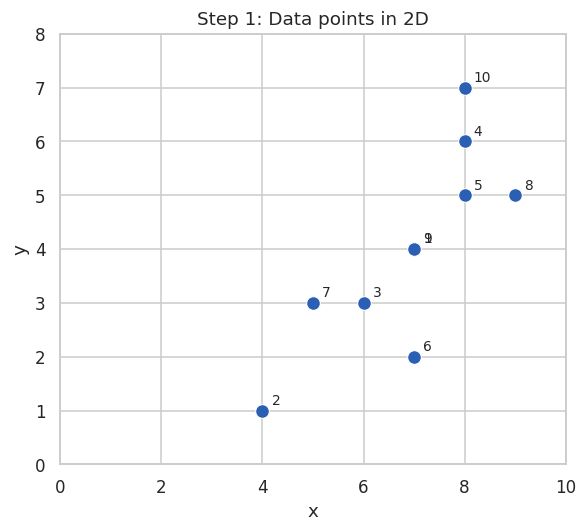

In [ ]:
data = pd.DataFrame({
    "Sample": range(1, 11),
    "x": [7, 4, 6, 8, 8, 7, 5, 9, 7, 8],
    "y": [4, 1, 3, 6, 5, 2, 3, 5, 4, 7],
}).set_index("Sample")

display(data)

X = data[["x", "y"]].to_numpy(dtype=float)   # data matrix, shape (n, 2)
n, p = X.shape
print(f"n = {n} samples, p = {p} features")

fig, ax = plt.subplots(figsize=(5.5, 5))
sns.scatterplot(data=data, x="x", y="y", s=80, color=BLUE, ax=ax)
for i, (xi, yi) in enumerate(X, start=1):
    ax.annotate(str(i), (xi, yi), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set(title="Step 1: Data points in 2D", xlabel="x", ylabel="y", xlim=(0, 10), ylim=(0, 8))
plt.tight_layout()
plt.show()

## Step 2 — Calculate Mean (plus Variance, Standard Deviation, Correlation)

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i \qquad
\bar{y} = \frac{1}{n}\sum_{i=1}^{n} y_i \qquad
\mu = \begin{bmatrix}\bar{x}\\ \bar{y}\end{bmatrix}$$

$$\text{Var}(x) = \frac{1}{n}\sum (x_i-\bar{x})^2 \qquad
\sigma_x = \sqrt{\text{Var}(x)} \qquad
\text{Cov}(x,y) = \frac{1}{n}\sum (x_i-\bar{x})(y_i-\bar{y}) \qquad
r = \frac{\text{Cov}(x,y)}{\sigma_x\,\sigma_y}$$

In [ ]:
mean_vec = X.mean(axis=0)
x_bar, y_bar = mean_vec

print("x̄ = (" + " + ".join(str(v) for v in data["x"]) + f") / {n} = {x_bar:.4f}")
print("ȳ = (" + " + ".join(str(v) for v in data["y"]) + f") / {n} = {y_bar:.4f}")
print(f"\nMean vector  μ = [{x_bar:.4f}, {y_bar:.4f}]")

x̄ = (7 + 4 + 6 + 8 + 8 + 7 + 5 + 9 + 7 + 8) / 10 = 6.9000
ȳ = (4 + 1 + 3 + 6 + 5 + 2 + 3 + 5 + 4 + 7) / 10 = 4.0000

Mean vector  μ = [6.9000, 4.0000]


In [ ]:
# Descriptive statistics for x and y
stats = pd.DataFrame({
    "Mean":                        data.mean(),
    "Median":                      data.median(),
    "Min":                         data.min(),
    "Max":                         data.max(),
    "Variance (population, ÷n)":  data.var(ddof=0),
    "Variance (sample, ÷n−1)":     data.var(ddof=1),
    "Std Dev (population, ÷n)":    data.std(ddof=0),
    "Std Dev (sample, ÷n−1)":      data.std(ddof=1),
}).T
display(stats)

# Manual calculation (population formulas) for x, y
var_x  = np.mean((data["x"] - x_bar) ** 2)
var_y  = np.mean((data["y"] - y_bar) ** 2)
cov_xy = np.mean((data["x"] - x_bar) * (data["y"] - y_bar))
sd_x, sd_y = np.sqrt(var_x), np.sqrt(var_y)
r = cov_xy / (sd_x * sd_y)

print(f"Var(x)    = {var_x:.4f}     σx = {sd_x:.4f}")
print(f"Var(y)    = {var_y:.4f}     σy = {sd_y:.4f}")
print(f"Cov(x, y) = {cov_xy:.4f}")
print(f"Correlation r(x, y) = {cov_xy:.4f} / ({sd_x:.4f} × {sd_y:.4f}) = {r:.4f}")

assert np.isclose(r, np.corrcoef(data["x"], data["y"])[0, 1])   # cross-check with NumPy

strength = "strong" if abs(r) >= 0.7 else "moderate" if abs(r) >= 0.4 else "weak"
print(f"\n→ x and y have a {strength} {'positive' if r > 0 else 'negative'} linear relationship.")

,x,y
Mean,6.9000,4.0000
Median,7.0000,4.0000
Min,4.0000,1.0000
Max,9.0000,7.0000
"Variance (population, ÷n)",2.0900,3.0000
"Variance (sample, ÷n−1)",2.3222,3.3333
"Std Dev (population, ÷n)",1.4457,1.7321
"Std Dev (sample, ÷n−1)",1.5239,1.8257


Var(x)    = 2.0900     σx = 1.4457
Var(y)    = 3.0000     σy = 1.7321
Cov(x, y) = 2.0000
Correlation r(x, y) = 2.0000 / (1.4457 × 1.7321) = 0.7987

→ x and y have a strong positive linear relationship.


## Step 3 — Center the Data

Subtract the mean from every observation so the cloud of points is centred on the origin:

$$X_c = X - \mu$$

,x_c,y_c
Sample,,
1,0.1000,0.0000
2,-2.9000,-3.0000
3,-0.9000,-1.0000
4,1.1000,2.0000
5,1.1000,1.0000
6,0.1000,-2.0000
7,-1.9000,-1.0000
8,2.1000,1.0000
9,0.1000,0.0000


Column means after centering (should be ~0): [-0.  0.]


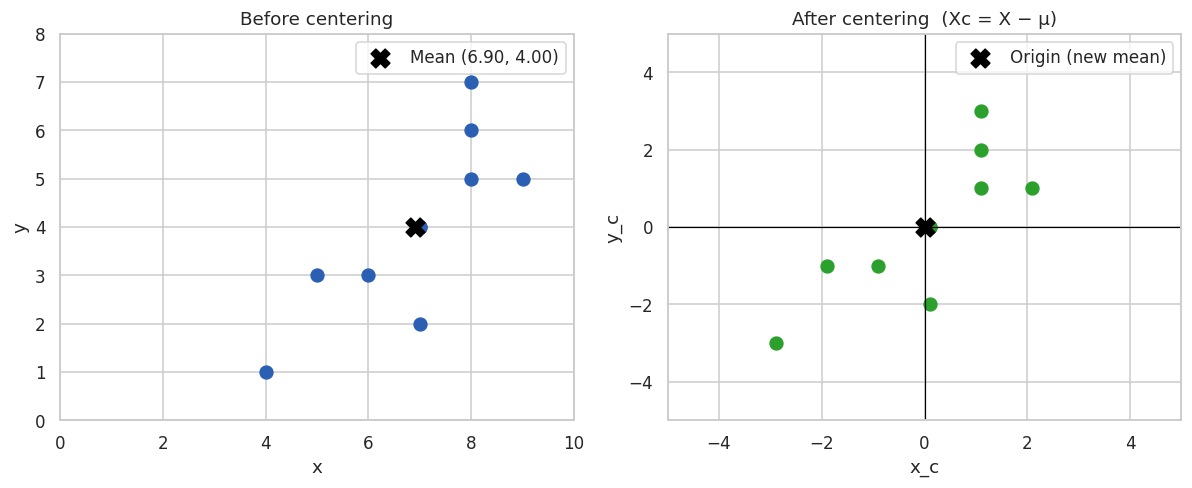

In [ ]:
Xc = X - mean_vec
centered = pd.DataFrame(Xc, columns=["x_c", "y_c"], index=data.index)
display(centered)
print("Column means after centering (should be ~0):", Xc.mean(axis=0).round(10))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharex=False)

axes[0].scatter(X[:, 0], X[:, 1], s=70, color=BLUE)
axes[0].scatter(*mean_vec, marker="X", s=150, color="black", label=f"Mean ({x_bar:.2f}, {y_bar:.2f})")
axes[0].set(title="Before centering", xlabel="x", ylabel="y", xlim=(0, 10), ylim=(0, 8))
axes[0].legend()

axes[1].scatter(Xc[:, 0], Xc[:, 1], s=70, color=GREEN)
axes[1].axhline(0, color="black", lw=0.8); axes[1].axvline(0, color="black", lw=0.8)
axes[1].scatter(0, 0, marker="X", s=150, color="black", label="Origin (new mean)")
axes[1].set(title="After centering  (Xc = X − μ)", xlabel="x_c", ylabel="y_c", xlim=(-5, 5), ylim=(-5, 5))
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 4 — Compute the Covariance Matrix

$$C = \frac{1}{n}\,X_c^{T}X_c
= \begin{bmatrix}\text{Var}(x) & \text{Cov}(x,y)\\ \text{Cov}(x,y) & \text{Var}(y)\end{bmatrix}$$

Covariance matrix C  (n = 10, ÷n):


,x,y
x,2.0900,2.0000
y,2.0000,3.0000


Sample covariance matrix (÷ n−1), for comparison:


,x,y
x,2.3222,2.2222
y,2.2222,3.3333


• Var(x)    = 2.0900
• Var(y)    = 3.0000
• Cov(x, y) = 2.0000


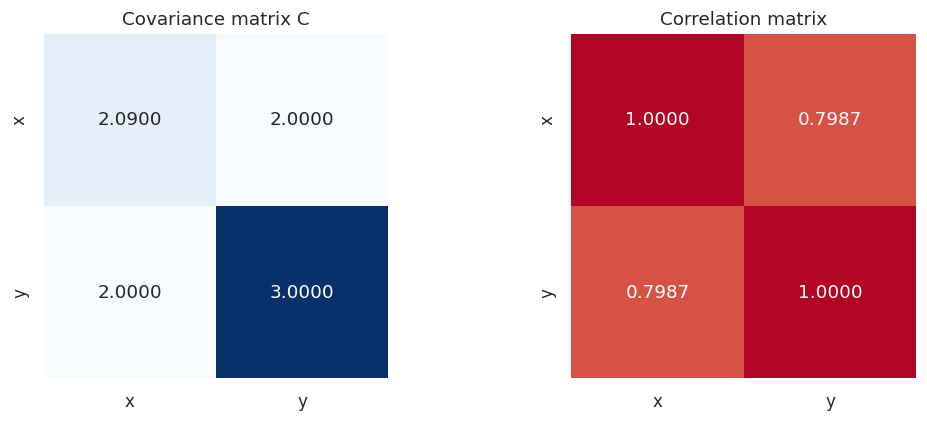

In [ ]:
C = (Xc.T @ Xc) / n                       # population covariance (÷ n), as in the reference sheet
C_sample = (Xc.T @ Xc) / (n - 1)          # sample covariance (÷ n−1), for comparison
labels = ["x", "y"]

cov_df = pd.DataFrame(C, index=labels, columns=labels)
print(f"Covariance matrix C  (n = {n}, ÷n):")
display(cov_df)

print("Sample covariance matrix (÷ n−1), for comparison:")
display(pd.DataFrame(C_sample, index=labels, columns=labels))

print(f"• Var(x)    = {C[0, 0]:.4f}")
print(f"• Var(y)    = {C[1, 1]:.4f}")
print(f"• Cov(x, y) = {C[0, 1]:.4f}")

# cross-check against NumPy
assert np.allclose(C, np.cov(X.T, bias=True))
assert np.allclose(C_sample, np.cov(X.T))

corr_matrix = pd.DataFrame(np.corrcoef(X.T), index=labels, columns=labels)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cov_df, annot=True, fmt=".4f", cmap="Blues", square=True, cbar=False, ax=axes[0])
axes[0].set_title("Covariance matrix C")
sns.heatmap(corr_matrix, annot=True, fmt=".4f", cmap="coolwarm", vmin=-1, vmax=1, square=True, cbar=False, ax=axes[1])
axes[1].set_title("Correlation matrix")
plt.tight_layout()
plt.show()

## Step 5 — Find Eigenvalues

Solve the characteristic equation

$$\det(C - \lambda I) = 0 \;\;\Longrightarrow\;\; \lambda^{2} - \operatorname{tr}(C)\,\lambda + \det(C) = 0$$

The eigenvalues are the variances of the data along the principal directions.

trace(C) = 5.0900
det(C)   = 2.2700
Characteristic equation:  λ² − 5.0900·λ + 2.2700 = 0

Roots of the quadratic (manual): [4.5961 0.4939]


,Eigenvalue,Explained variance (%),Cumulative (%)
PC1 (λ₁),4.5961,90.2967,90.2967
PC2 (λ₂),0.4939,9.7033,100.0000


λ₁ = 4.5961      λ₂ = 0.4939
Explained variance:  PC1 = 90.30%    PC2 = 9.70%
Check: λ₁ + λ₂ = 5.0900 = Var(x) + Var(y) = 5.0900


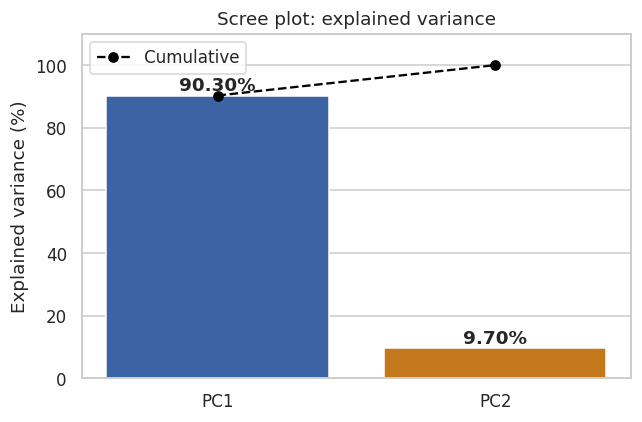

In [ ]:
trace_C = np.trace(C)
det_C = np.linalg.det(C)
print(f"trace(C) = {trace_C:.4f}")
print(f"det(C)   = {det_C:.4f}")
print(f"Characteristic equation:  λ² − {trace_C:.4f}·λ + {det_C:.4f} = 0")

# Manual: quadratic formula
disc = trace_C ** 2 - 4 * det_C
lam_manual = np.array([(trace_C + np.sqrt(disc)) / 2, (trace_C - np.sqrt(disc)) / 2])
print("\nRoots of the quadratic (manual):", lam_manual)

# NumPy (eigh is for symmetric matrices); sort in descending order
eigvals, eigvecs = np.linalg.eigh(C)
order = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]
assert np.allclose(lam_manual, eigvals)

lam1, lam2 = eigvals
explained = eigvals / eigvals.sum()

ev_table = pd.DataFrame({
    "Eigenvalue": eigvals,
    "Explained variance (%)": explained * 100,
    "Cumulative (%)": np.cumsum(explained) * 100,
}, index=["PC1 (λ₁)", "PC2 (λ₂)"])
display(ev_table)

print(f"λ₁ = {lam1:.4f}      λ₂ = {lam2:.4f}")
print(f"Explained variance:  PC1 = {explained[0]*100:.2f}%    PC2 = {explained[1]*100:.2f}%")
print(f"Check: λ₁ + λ₂ = {eigvals.sum():.4f} = Var(x) + Var(y) = {C[0,0] + C[1,1]:.4f}")

# Scree plot
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=["PC1", "PC2"], y=explained * 100, hue=["PC1", "PC2"], palette=[BLUE, ORANGE], legend=False, ax=ax)
ax.plot(["PC1", "PC2"], np.cumsum(explained) * 100, "o--", color="black", label="Cumulative")
for i, v in enumerate(explained * 100):
    ax.text(i, v + 1.5, f"{v:.2f}%", ha="center", fontweight="bold")
ax.set(title="Scree plot: explained variance", ylabel="Explained variance (%)", ylim=(0, 110))
ax.legend()
plt.tight_layout()
plt.show()

## Step 6 — Find Eigenvectors

For each eigenvalue solve $(C - \lambda I)\,v = 0$ and normalise to unit length.
The sign of an eigenvector is arbitrary; we choose the sign so that the *y*-component is positive.

In [ ]:
# Sign convention: y-component positive
for j in range(eigvecs.shape[1]):
    if eigvecs[1, j] < 0:
        eigvecs[:, j] *= -1

v1, v2 = eigvecs[:, 0], eigvecs[:, 1]

# Manual solve for a 2×2 matrix: (C − λI)v = 0  →  v ∝ [ Cov(x,y),  λ − Var(x) ]
def manual_eigvec(lam):
    v = np.array([C[0, 1], lam - C[0, 0]])
    return v / np.linalg.norm(v)

print(f"PC1 (λ₁ = {lam1:.4f}):  v₁ = {v1}")
print(f"PC2 (λ₂ = {lam2:.4f}):  v₂ = {v2}")

# Cross-checks
assert np.allclose(v1, manual_eigvec(lam1)) and np.allclose(np.abs(v2), np.abs(manual_eigvec(lam2)))
print("\nCheck  C·v = λ·v :")
print(f"   C·v₁ = {C @ v1}   λ₁·v₁ = {lam1 * v1}")
print(f"   C·v₂ = {C @ v2}   λ₂·v₂ = {lam2 * v2}")

print(f"\n‖v₁‖ = {np.linalg.norm(v1):.4f},  ‖v₂‖ = {np.linalg.norm(v2):.4f}")
print(f"v₁ · v₂ = {abs(v1 @ v2):.6f}  ≈ 0  → the eigenvectors are orthogonal")

display(pd.DataFrame(eigvecs, index=["x", "y"], columns=["v₁ (PC1)", "v₂ (PC2)"]))

PC1 (λ₁ = 4.5961):  v₁ = [0.6238 0.7816]
PC2 (λ₂ = 0.4939):  v₂ = [-0.7816  0.6238]

Check  C·v = λ·v :
   C·v₁ = [2.8669 3.5924]   λ₁·v₁ = [2.8669 3.5924]
   C·v₂ = [-0.386   0.3081]   λ₂·v₂ = [-0.386   0.3081]

‖v₁‖ = 1.0000,  ‖v₂‖ = 1.0000
v₁ · v₂ = 0.000000  ≈ 0  → the eigenvectors are orthogonal


,v₁ (PC1),v₂ (PC2)
x,0.6238,-0.7816
y,0.7816,0.6238


## Step 7 — Data with Principal Components

The principal components are the new axes through the mean: **PC1** points in the direction of maximum variance, **PC2** is perpendicular to it.

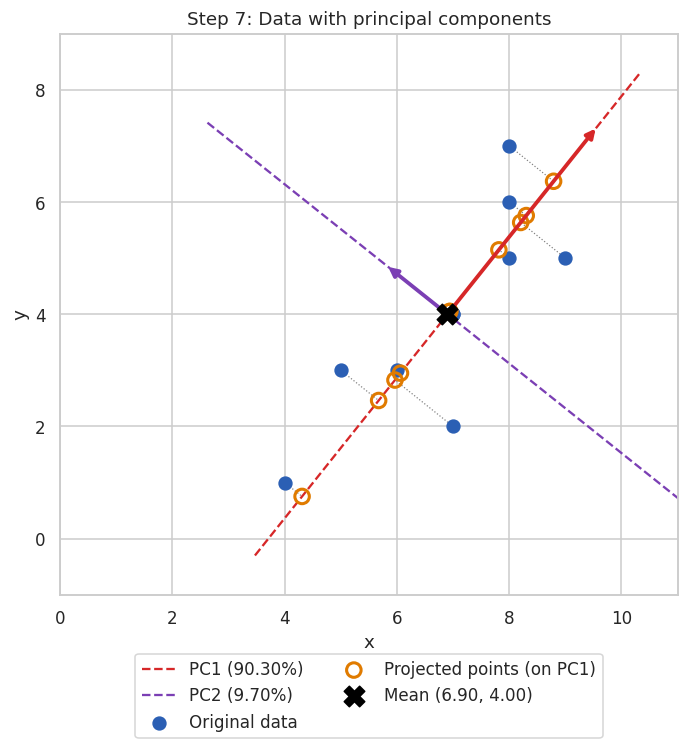

In [ ]:
mu = mean_vec
z = Xc @ v1                              # PC1 scores (used again in Steps 8 & 9)
proj_xy = mu + np.outer(z, v1)           # projected points expressed in the original x–y plane

fig, ax = plt.subplots(figsize=(8, 7))

# projection lines: original point → its projection on PC1
for (x0, y0), (x1, y1) in zip(X, proj_xy):
    ax.plot([x0, x1], [y0, y1], color="gray", lw=0.8, ls=":", zorder=1)

# PC axes through the mean
t = np.linspace(-5.5, 5.5, 2)
ax.plot(*(mu[:, None] + np.outer(v1, t)), color=RED, lw=1.5, ls="--", zorder=2,
        label=f"PC1 ({explained[0]*100:.2f}%)")
ax.plot(*(mu[:, None] + np.outer(v2, t)), color=PURPLE, lw=1.5, ls="--", zorder=2,
        label=f"PC2 ({explained[1]*100:.2f}%)")

# arrows showing eigenvector directions, scaled by √λ
for v, lam, c in [(v1, lam1, RED), (v2, lam2, PURPLE)]:
    ax.annotate("", xy=mu + 2 * np.sqrt(lam) * v, xytext=mu,
                arrowprops=dict(arrowstyle="-|>", color=c, lw=2.5), zorder=4)

ax.scatter(X[:, 0], X[:, 1], s=70, color=BLUE, label="Original data", zorder=3)
ax.scatter(proj_xy[:, 0], proj_xy[:, 1], s=90, facecolors="none", edgecolors=ORANGE, linewidths=2,
           label="Projected points (on PC1)", zorder=3)
ax.scatter(*mu, marker="X", s=180, color="black", label=f"Mean ({x_bar:.2f}, {y_bar:.2f})", zorder=5)

ax.set(title="Step 7: Data with principal components", xlabel="x", ylabel="y", xlim=(0, 11), ylim=(-1, 9))
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.09), ncol=2, frameon=True)
plt.tight_layout()
plt.show()

## Step 8 — Project $X_c$ onto PC1

For each centred point, the PC1 score is the dot product with $v_1$:

$$z_i = X_{c,i}\cdot v_1 = v_{1x}\,x_{c,i} + v_{1y}\,y_{c,i}$$

In [ ]:
print(f"z_i = {v1[0]:.4f}·x_c,i + {v1[1]:.4f}·y_c,i\n")

projection = pd.DataFrame({
    "x_c": Xc[:, 0],
    "y_c": Xc[:, 1],
    "PC1 projection (z)": z,
}, index=data.index)
display(projection)

# optional: scores on both PCs (full rotation into the PC coordinate system)
scores = Xc @ eigvecs
print("Variance of PC scores (÷n) →", scores.var(axis=0), " = eigenvalues", eigvals)

z_i = 0.6238·x_c,i + 0.7816·y_c,i



,x_c,y_c,PC1 projection (z)
Sample,,,
1,0.1000,0.0000,0.0624
2,-2.9000,-3.0000,-4.1538
3,-0.9000,-1.0000,-1.3430
4,1.1000,2.0000,2.2494
5,1.1000,1.0000,1.4678
6,0.1000,-2.0000,-1.5008
7,-1.9000,-1.0000,-1.9668
8,2.1000,1.0000,2.0915
9,0.1000,0.0000,0.0624


Variance of PC scores (÷n) → [4.5961 0.4939]  = eigenvalues [4.5961 0.4939]


## Step 9 — 2D → 1D Representation

Each sample is now described by **one number** (its coordinate along PC1) instead of two.

Projected data (along PC1):
[ 0.0624 -4.1538 -1.343   2.2494  1.4678 -1.5008 -1.9668  2.0915  0.0624
  3.031 ]

Variance retained by PC1: 90.30%


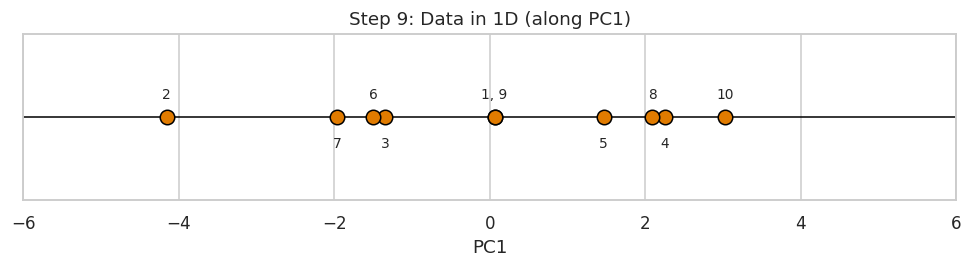

Mean squared reconstruction error = 0.4939  (equals the discarded eigenvalue λ₂ = 0.4939)


In [ ]:
print("Projected data (along PC1):")
print(np.round(z, 4))
print(f"\nVariance retained by PC1: {explained[0]*100:.2f}%")

# 1-D number line plot
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.axhline(0, color="black", lw=1)
ax.scatter(z, np.zeros_like(z), s=90, color=ORANGE, edgecolor="black", zorder=3)
# label each point with its sample number(s); samples with identical scores share one label (e.g. "1, 9")
groups = pd.Series(range(1, n + 1)).groupby(np.round(z, 4)).apply(lambda s: ", ".join(map(str, s)))
for k, (zi, lab) in enumerate(groups.items()):
    ax.annotate(lab, (zi, 0), xytext=(0, 12 if k % 2 == 0 else -20), textcoords="offset points",
                ha="center", fontsize=9)
lim = np.ceil(np.abs(z).max()) + 1
ax.set(xlim=(-lim, lim), ylim=(-0.6, 0.6), xlabel="PC1", title="Step 9: Data in 1D (along PC1)")
ax.set_yticks([])
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

# Reconstruction: how much information did we lose by going from 2D to 1D?
X_hat = mu + np.outer(z, v1)
recon_err = np.mean(np.sum((X - X_hat) ** 2, axis=1))
print(f"Mean squared reconstruction error = {recon_err:.4f}  (equals the discarded eigenvalue λ₂ = {lam2:.4f})")

## Cross-check with scikit-learn

Everything above was computed manually with NumPy. Here we confirm the results with `sklearn.decomposition.PCA`.
(scikit-learn divides by *n−1*, so its `explained_variance_` equals our eigenvalues × n/(n−1); the ratios and directions are identical. Signs of components may differ.)

In [ ]:
pca = PCA(n_components=2)
Z_sk = pca.fit_transform(X)

print("sklearn explained_variance_ratio_ :", pca.explained_variance_ratio_)
print("our explained variance ratio      :", explained)
print("\nsklearn explained_variance_ (÷n−1):", pca.explained_variance_)
print("our eigenvalues × n/(n−1)          :", eigvals * n / (n - 1))
print("\nsklearn components_ (rows = PCs):\n", pca.components_)
print("our eigenvectors (rows = PCs):\n", eigvecs.T)

print("\nSame directions (up to sign)?   ", np.allclose(np.abs(pca.components_), np.abs(eigvecs.T)))
print("Same PC1 scores (up to sign)?   ", np.allclose(np.abs(Z_sk[:, 0]), np.abs(z)))

sklearn explained_variance_ratio_ : [0.903 0.097]
our explained variance ratio      : [0.903 0.097]

sklearn explained_variance_ (÷n−1): [5.1068 0.5488]
our eigenvalues × n/(n−1)          : [5.1068 0.5488]

sklearn components_ (rows = PCs):
 [[ 0.6238  0.7816]
 [ 0.7816 -0.6238]]
our eigenvectors (rows = PCs):
 [[ 0.6238  0.7816]
 [-0.7816  0.6238]]

Same directions (up to sign)?    True
Same PC1 scores (up to sign)?    True


## Summary of Results

In [ ]:
print("=" * 58)
print("PCA SUMMARY  (n = 10 samples, 2 features)")
print("=" * 58)
print(f"1. Mean vector μ          : [{x_bar:.4f}, {y_bar:.4f}]")
print(f"2. Variance  (÷n)         : Var(x) = {C[0,0]:.4f},  Var(y) = {C[1,1]:.4f}")
print(f"   Std dev   (÷n)         : σx = {sd_x:.4f},  σy = {sd_y:.4f}")
print(f"3. Covariance Cov(x,y)    : {C[0,1]:.4f}")
print(f"   Correlation r(x,y)     : {r:.4f}")
print(f"4. Covariance matrix C    : {C.round(4).tolist()}")
print(f"5. Eigenvalues            : λ₁ = {lam1:.4f},  λ₂ = {lam2:.4f}")
print(f"6. Eigenvectors           : v₁ = {v1.round(4)},  v₂ = {v2.round(4)}")
print(f"   Explained variance     : PC1 = {explained[0]*100:.2f}%,  PC2 = {explained[1]*100:.2f}%")
print(f"7. 1-D representation (z) : {np.round(z, 4).tolist()}")
print("=" * 58)
print("PCA finds a new coordinate system in which the data is most spread out,")
print("then projects the data onto the first component for a lower-dimensional view.")

PCA SUMMARY  (n = 10 samples, 2 features)
1. Mean vector μ          : [6.9000, 4.0000]
2. Variance  (÷n)         : Var(x) = 2.0900,  Var(y) = 3.0000
   Std dev   (÷n)         : σx = 1.4457,  σy = 1.7321
3. Covariance Cov(x,y)    : 2.0000
   Correlation r(x,y)     : 0.7987
4. Covariance matrix C    : [[2.09, 2.0], [2.0, 3.0]]
5. Eigenvalues            : λ₁ = 4.5961,  λ₂ = 0.4939
6. Eigenvectors           : v₁ = [0.6238 0.7816],  v₂ = [-0.7816  0.6238]
   Explained variance     : PC1 = 90.30%,  PC2 = 9.70%
7. 1-D representation (z) : [0.0624, -4.1538, -1.343, 2.2494, 1.4678, -1.5008, -1.9668, 2.0915, 0.0624, 3.031]
PCA finds a new coordinate system in which the data is most spread out,
then projects the data onto the first component for a lower-dimensional view.
